In [56]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Parameters ──────────────────────────────────────────────────────────────
LATTICE  = 'rectangular'  # 'rectangular'  or  'triangular'
N_STEPS  = 100000            # maximum number of steps before the walk stops
SEED     = None           # integer for reproducibility, None for random

In [57]:
# ── Lattice neighbour functions ──────────────────────────────────────────────
#
# Rectangular lattice uses plain (x, y) integer coordinates.
#
# Triangular lattice uses *axial* (q, r) coordinates:
#   every vertex has 6 neighbours in the six axial directions.
#   Cartesian embedding: x = q + r/2,  y = r·√3/2

def neighbours_rect(pos):
    x, y = pos
    return [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]

def neighbours_tri(pos):
    q, r = pos
    return [(q+1,r), (q-1,r), (q,r+1), (q,r-1), (q+1,r-1), (q-1,r+1)]

NEIGHBOUR_FN = {'rectangular': neighbours_rect, 'triangular': neighbours_tri}

def to_cartesian(pos, lattice):
    if lattice == 'rectangular':
        return pos
    q, r = pos
    return (q + r * 0.5, r * np.sqrt(3) / 2)

In [58]:
# ── Self-avoiding walk generator ─────────────────────────────────────────────
#
# At every step we pick uniformly from neighbours that have NOT been visited.
# The walk stops when it reaches N_STEPS or gets trapped (no free neighbours).

def generate_saw(lattice, n_steps, seed=None):
    rng = np.random.default_rng(seed)
    get_nbrs = NEIGHBOUR_FN[lattice]

    start   = (int(0), int(0))
    path    = [start]
    visited = {start}

    for _ in range(n_steps):
        available = [n for n in get_nbrs(path[-1]) if n not in visited]
        if not available:
            break
        nxt = available[rng.integers(len(available))]
        path.append(nxt)
        visited.add(nxt)

    return path

In [59]:
# ── Visualisation ────────────────────────────────────────────────────────────

def visualise_saw(path, lattice, n_max, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    else:
        fig = ax.figure

    coords = np.array([to_cartesian(p, lattice) for p in path])  # shape (L, 2)
    L = len(coords)

    cmap = plt.cm.plasma
    norm = mcolors.Normalize(vmin=0, vmax=L - 2)

    # Draw each segment coloured by step index
    for i in range(L - 1):
        ax.plot(coords[i:i+2, 0], coords[i:i+2, 1],
                color=cmap(norm(i)), linewidth=1.8, solid_capstyle='round')

    ax.scatter(*coords[0],  color='lime',  s=120, zorder=6, label='Start', edgecolors='k', linewidths=0.6)
    ax.scatter(*coords[-1], color='red',   s=120, zorder=6, label='End',   edgecolors='k', linewidths=0.6, marker='X')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Step', fraction=0.035, pad=0.04)

    steps_taken = L - 1
    stuck  = steps_taken < n_max
    status = f'stuck after {steps_taken} steps' if stuck else f'completed {steps_taken} steps'
    ax.set_title(f'SAW on {lattice} lattice  —  {status}', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    return fig, ax

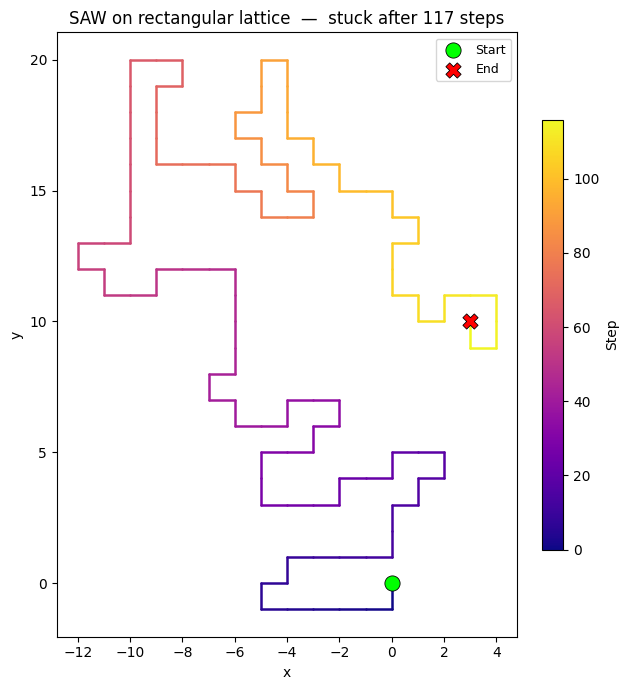

Lattice  : rectangular
Steps    : 117 / 100000
Start    : (0, 0)
End      : (3, 10)
Walk got trapped — no unvisited neighbours remained.


In [61]:
# ── Run and plot a single walk ────────────────────────────────────────────────

path = generate_saw(LATTICE, N_STEPS, SEED)

fig, ax = visualise_saw(path, LATTICE, N_STEPS)
plt.tight_layout()
plt.show()

steps_taken = len(path) - 1
print(f'Lattice  : {LATTICE}')
print(f'Steps    : {steps_taken} / {N_STEPS}')
print(f'Start    : {path[0]}')
print(f'End      : {path[-1]}')
if steps_taken < N_STEPS:
    print('Walk got trapped — no unvisited neighbours remained.')
else:
    print('Walk reached the step limit without getting stuck.')

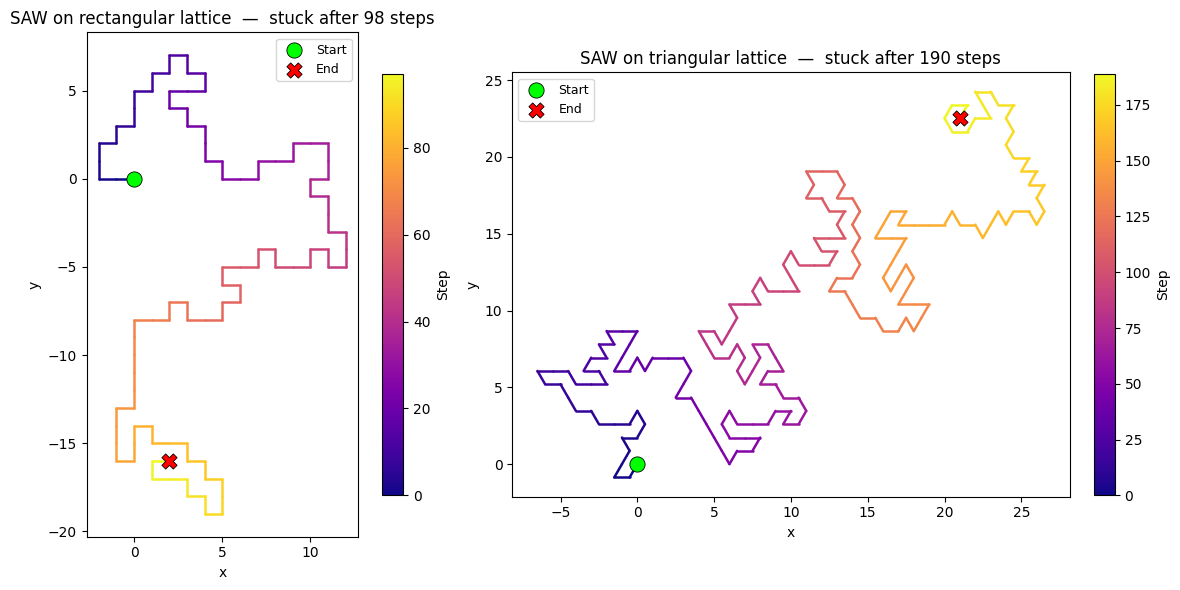

In [62]:
# ── Side-by-side: rectangular vs triangular ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lat in zip(axes, ['rectangular', 'triangular']):
    p = generate_saw(lat, N_STEPS, SEED)
    visualise_saw(p, lat, N_STEPS, ax=ax)
plt.tight_layout()
plt.show()

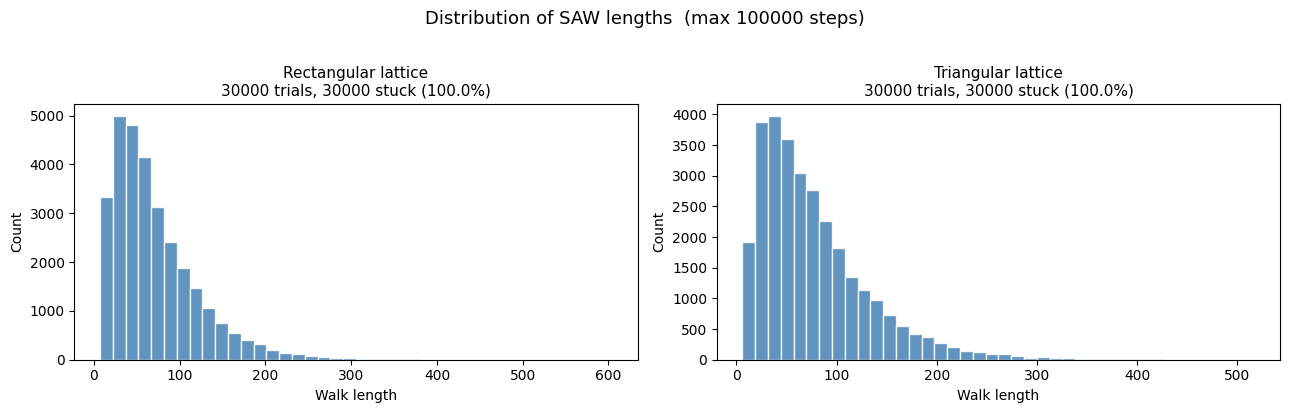

Mean lengths: {'rectangular': '70.9', 'triangular': '77.5'}


In [75]:
# ── Walk-length statistics over many trials ───────────────────────────────────
#
# On the square lattice the critical exponent ν ≈ 0.75 governs how the
# end-to-end distance scales with walk length: <|r|²> ~ N^{2ν}.
# Here we just plot the distribution of walk lengths.

N_TRIALS = 30000

all_lengths = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, lat in zip(axes, ['rectangular', 'triangular']):
    lengths = np.array([len(generate_saw(lat, N_STEPS)) - 1 for _ in range(N_TRIALS)])
    all_lengths[lat] = lengths
    n_stuck = np.sum(lengths < N_STEPS)

    ax.hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)

    # Only draw the N_STEPS line if it falls within the plotted range
    if N_STEPS <= lengths.max() * 1.2:
        ax.axvline(N_STEPS, color='red', linestyle='--', linewidth=1.2, label=f'limit N={N_STEPS}')
        ax.legend(fontsize=9)

    ax.set_title(f'{lat.capitalize()} lattice\n'
                 f'{N_TRIALS} trials, {n_stuck} stuck ({100*n_stuck/N_TRIALS:.1f}%)', fontsize=11)
    ax.set_xlabel('Walk length')
    ax.set_ylabel('Count')

plt.suptitle(f'Distribution of SAW lengths  (max {N_STEPS} steps)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Mean lengths:', {lat: f'{lengths.mean():.1f}' for lat, lengths in all_lengths.items()})


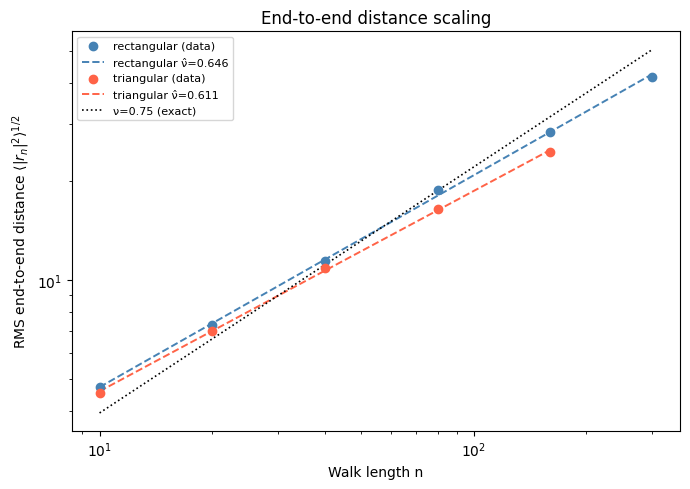

In [65]:
# ── End-to-end distance scaling ───────────────────────────────────────────────
#
# For a self-avoiding walk of length n on the square lattice,
# <|r_n|²>^{1/2} ~ n^ν  with ν = 3/4  (exact in 2D, Nienhuis 1982).
# On the triangular lattice the same exponent holds (same universality class).
# We estimate ν empirically by running walks of varying max length.

REPS   = 300
ns     = [10, 20, 40, 80, 160, 300]

fig, ax = plt.subplots(figsize=(7, 5))

for lat, color in [('rectangular', 'steelblue'), ('triangular', 'tomato')]:
    rms = []
    for n in ns:
        dists_sq = []
        for _ in range(REPS):
            p = generate_saw(lat, n)
            if len(p) - 1 == n:          # only count walks that reached n steps
                ex, ey = to_cartesian(p[-1], lat)
                dists_sq.append(ex**2 + ey**2)
        if dists_sq:
            rms.append((n, np.sqrt(np.mean(dists_sq))))
    if len(rms) < 2:
        continue
    ns_fit, rms_fit = zip(*rms)
    ax.scatter(ns_fit, rms_fit, color=color, zorder=4, label=f'{lat} (data)')

    # Log-linear fit to estimate ν
    log_n   = np.log(ns_fit)
    log_rms = np.log(rms_fit)
    nu_hat, log_c = np.polyfit(log_n, log_rms, 1)
    n_plot = np.linspace(min(ns_fit), max(ns_fit), 200)
    ax.plot(n_plot, np.exp(log_c) * n_plot**nu_hat, color=color,
            linestyle='--', linewidth=1.4, label=f'{lat} ν̂={nu_hat:.3f}')

# Reference ν = 3/4
n_ref = np.array(ns)
ax.plot(n_ref, 0.7 * n_ref**0.75, 'k:', linewidth=1.2, label='ν=0.75 (exact)')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Walk length n')
ax.set_ylabel(r'RMS end-to-end distance $\langle |r_n|^2 \rangle^{1/2}$')
ax.set_title('End-to-end distance scaling')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [66]:

# ── Per-walk metric computation ───────────────────────────────────────────────
#
# All distances are measured in the Cartesian embedding of the lattice, so
# results are geometrically comparable across lattice types.
#
# Three norms from the origin, evaluated at every visited site:
#   L1  (Manhattan / taxicab):  |x| + |y|
#   L2  (Euclidean):            √(x² + y²)
#   L∞  (Chebyshev / sup):     max(|x|, |y|)
#
# Per walk we record:
#   length   – steps taken (< N_STEPS when stuck)
#   max_l*   – maximum norm achieved over all visited sites
#   end_l*   – norm of the final position (end-to-end distance)

def walk_metrics(path, lattice):
    coords = np.array([to_cartesian(p, lattice) for p in path], dtype=float)
    l1   = np.abs(coords).sum(axis=1)
    l2   = np.sqrt((coords**2).sum(axis=1))
    linf = np.abs(coords).max(axis=1)
    return dict(
        length   = len(path) - 1,
        max_l1   = l1.max(),   max_l2   = l2.max(),   max_linf = linf.max(),
        end_l1   = l1[-1],     end_l2   = l2[-1],     end_linf = linf[-1],
    )


def expected_metrics(lattice, n_steps, n_trials=1000, seed=None):
    """
    Monte-Carlo estimate of E[metric] ± SE over n_trials independent walks.

    Returns a flat dict with entries for each metric key:
      key     – sample mean
      key_se  – standard error of the mean  (std / √n_trials)
    """
    rng     = np.random.default_rng(seed)
    records = [
        walk_metrics(generate_saw(lattice, n_steps, int(rng.integers(2**31))), lattice)
        for _ in range(n_trials)
    ]
    keys = records[0].keys()
    data = {k: np.array([r[k] for r in records]) for k in keys}
    out  = {}
    for k, vals in data.items():
        out[k]         = float(vals.mean())
        out[k + '_se'] = float(vals.std(ddof=1) / np.sqrt(n_trials))
    return out


In [70]:

# ── Expected-value table for both lattices at current N_STEPS ─────────────────

N_TRIALS_TABLE = 30000

lattices = ['rectangular', 'triangular']
print(f'Computing {N_TRIALS_TABLE} trials per lattice  (N_STEPS={N_STEPS}) …')
ev = {lat: expected_metrics(lat, N_STEPS, n_trials=N_TRIALS_TABLE) for lat in lattices}
print('Done.\n')

# ── formatted table ────────────────────────────────────────────────────────────

def fmt_ms(mean, se):
    """Format a mean ± SE pair to a fixed-width string."""
    return f'{mean:7.3f} ± {se:.3f}'

def row(label, *pairs):
    """pairs: sequence of (mean, se) or (None, None) for blank cells."""
    cells = '  '.join(fmt_ms(m, s) if m is not None else ' ' * 15 for m, s in pairs)
    return f'{label:<22}  {cells}'

lat_header  = '  '.join(f'{lat:^32}' for lat in lattices)
norm_header = '  '.join('  '.join(f'{"(" + n + ")":^15}' for n in ['L1', 'L2', 'L∞']) for _ in lattices)
sep = '─' * (22 + 2 + len(norm_header))

print(f'Expected values  (N_STEPS={N_STEPS}, n_trials={N_TRIALS_TABLE})')
print(f'{"":22}  {lat_header}')
print(f'{"Metric":<22}  {norm_header}')
print(sep)

def pairs(lat, base):
    return [(ev[lat][f'{base}_{n}'], ev[lat][f'{base}_{n}_se']) for n in ['l1', 'l2', 'linf']]

print(row('Run length',
          (ev['rectangular']['length'], ev['rectangular']['length_se']), (None, None), (None, None),
          (ev['triangular']['length'],  ev['triangular']['length_se']),  (None, None), (None, None)))

print(row('Max distance',        *pairs('rectangular', 'max'), *pairs('triangular', 'max')))
print(row('End-to-end distance', *pairs('rectangular', 'end'), *pairs('triangular', 'end')))

print(sep)
print('\nSE = standard error of the mean  =  σ / √n_trials  (95% CI ≈ ±2·SE)')
print('Distances in Cartesian units  |  triangular: x = q + r/2,  y = r√3/2')


Computing 30000 trials per lattice  (N_STEPS=100000) …
Done.

Expected values  (N_STEPS=100000, n_trials=30000)
                                  rectangular                        triangular           
Metric                       (L1)             (L2)             (L∞)             (L1)             (L2)             (L∞)      
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Run length               70.772 ± 0.292                                     76.290 ± 0.317                                  
Max distance             20.395 ± 0.072   15.614 ± 0.055   14.104 ± 0.051   20.003 ± 0.071   15.387 ± 0.055   14.110 ± 0.050
End-to-end distance      15.088 ± 0.068   11.871 ± 0.053   10.687 ± 0.048   14.870 ± 0.067   11.689 ± 0.052   10.526 ± 0.047
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

SE = standard error of the mean  =  σ / √n_tri

In [ ]:

# ── Scaling of expected metrics with N (log-log plots with error bars) ─────────
#
# On a log-log scale, a power law  E[X] ~ N^α  appears as a straight line
# with slope α.  For the Euclidean end-to-end distance the exact 2D exponent
# is α = ν = 3/4; we check the other norms and the max-distance exponent too.
#
# Error bars show ±1 SE (standard error of the mean).

N_VALS          = [5, 10, 20, 40, 80, 160, 300]
N_TRIALS_SCALE  = 600

lat_styles = {
    'rectangular': dict(color='steelblue', marker='o'),
    'triangular':  dict(color='tomato',    marker='s'),
}

print('Running scaling sweeps …')
scale_ev = {}
for lat in ['rectangular', 'triangular']:
    scale_ev[lat] = [expected_metrics(lat, n, n_trials=N_TRIALS_SCALE) for n in N_VALS]
    print(f'  {lat} done')

ns = np.array(N_VALS)


def power_fit(lat, key):
    """Return (means, std_errors, fitted_exponent, fitted_prefactor)."""
    y  = np.array([d[key]          for d in scale_ev[lat]])
    ye = np.array([d[key + '_se']  for d in scale_ev[lat]])
    alpha, log_c = np.polyfit(np.log(ns), np.log(y), 1)
    return y, ye, alpha, np.exp(log_c)


# ── Figure 1: max distance and end-to-end, one column per norm ────────────────
norms       = ['l1',         'l2',         'linf']
norm_labels = ['L1 (Manhattan)', 'L2 (Euclidean)', 'L∞ (Chebyshev)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
row_keys = [('max_{norm}', 'Max distance'),
            ('end_{norm}', 'End-to-end distance')]

for row_idx, (key_tpl, row_label) in enumerate(row_keys):
    for col_idx, (norm, nlabel) in enumerate(zip(norms, norm_labels)):
        ax  = axes[row_idx, col_idx]
        key = key_tpl.format(norm=norm)

        for lat, sty in lat_styles.items():
            y, ye, alpha, c = power_fit(lat, key)
            ax.errorbar(ns, y, yerr=ye,
                        linestyle='none', capsize=3, capthick=1,
                        elinewidth=1, **sty, markersize=6, label=lat)
            n_fit = np.linspace(ns[0], ns[-1], 200)
            ax.plot(n_fit, c * n_fit**alpha, linestyle='--',
                    color=sty['color'], alpha=0.6, linewidth=1.4,
                    label=f'α̂={alpha:.3f}')

        # Reference line for ν = 3/4 on L2 end-to-end
        if row_idx == 1 and norm == 'l2':
            ax.plot(ns, 0.65 * ns**0.75, 'k:', linewidth=1.2, label='ν=0.75')

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_title(f'{row_label}\n{nlabel}', fontsize=10)
        if col_idx == 0:
            ax.set_ylabel('Expected distance (log scale)', fontsize=9)
        if row_idx == 1:
            ax.set_xlabel('N_STEPS (log scale)', fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle('Expected distance metrics vs. max steps N  (error bars = ±1 SE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# ── Figure 2: expected run length with error bars ─────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
for lat, sty in lat_styles.items():
    y  = np.array([d['length']     for d in scale_ev[lat]])
    ye = np.array([d['length_se']  for d in scale_ev[lat]])
    ax.errorbar(ns, y, yerr=ye, linestyle='-', capsize=3, capthick=1,
                elinewidth=1, linewidth=1.8, label=lat, **sty)

ax.plot(ns, ns, 'k:', linewidth=1.1, label='E[length]=N  (never stuck)')
ax.set_xscale('log')
ax.set_xlabel('N_STEPS (log scale)')
ax.set_ylabel('E[run length]')
ax.set_title('Expected run length vs. N_STEPS  (error bars = ±1 SE)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
